Titanic dataset loaded successfully!

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4  

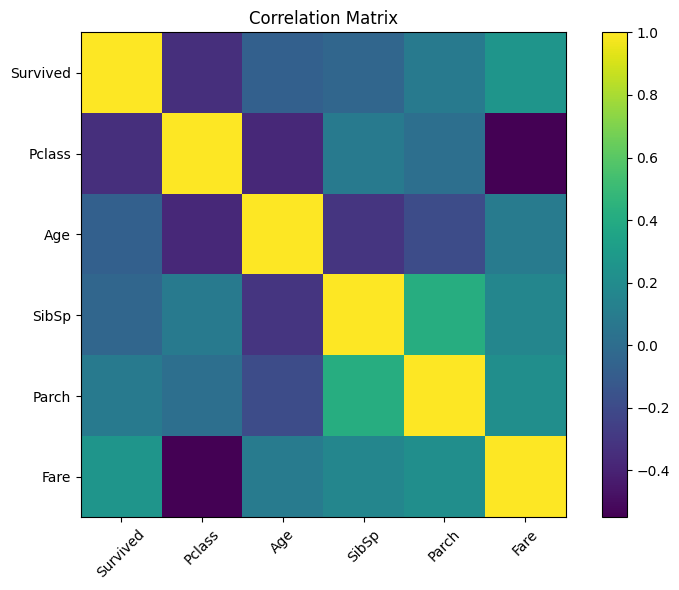

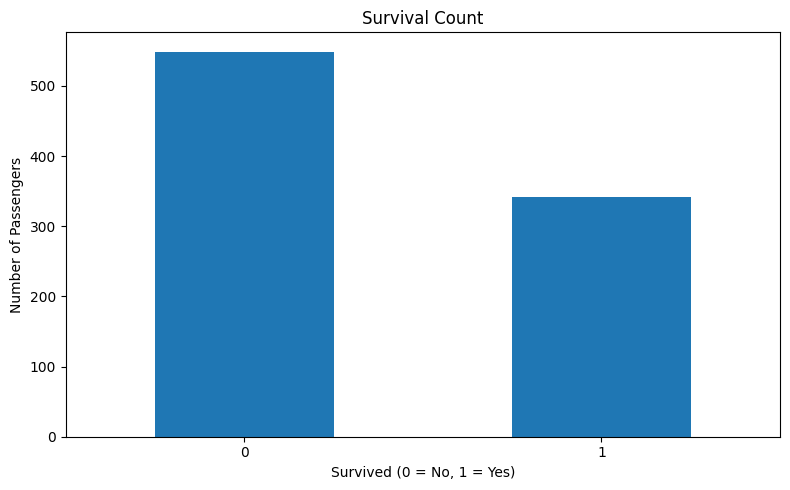

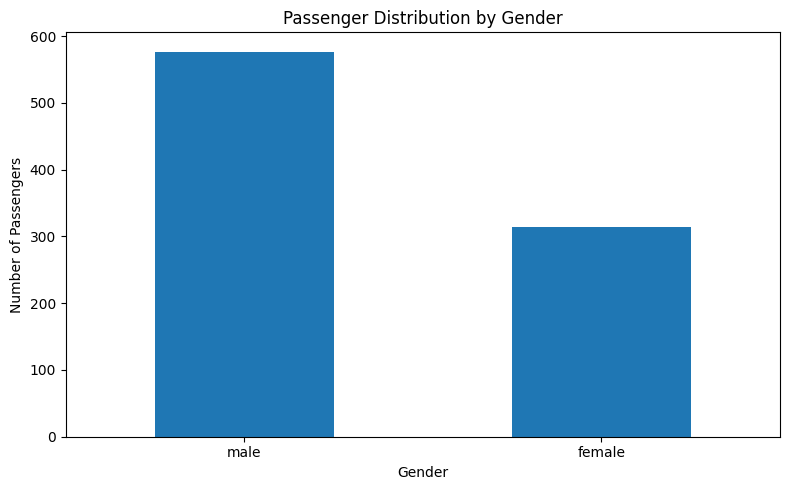

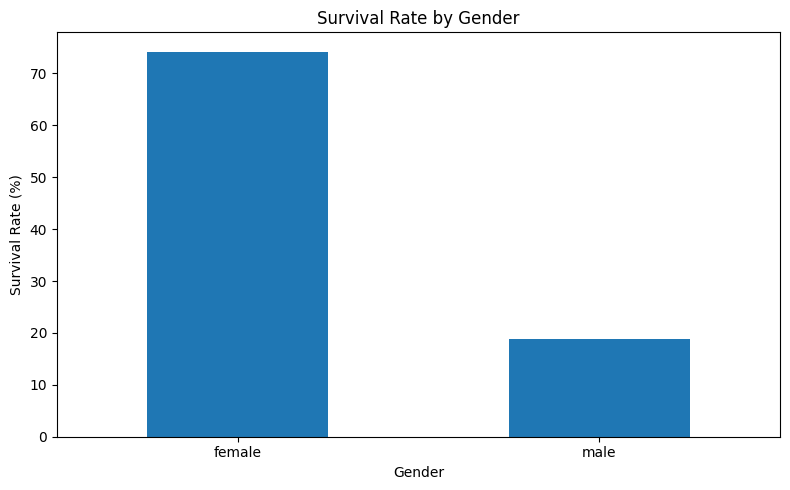

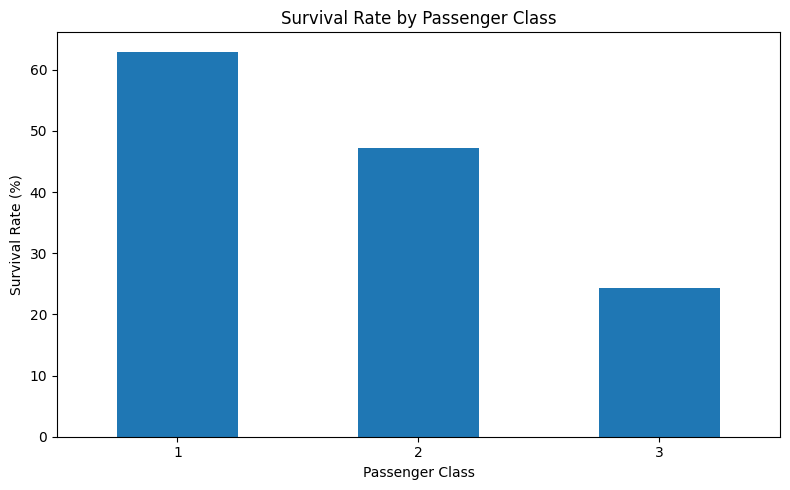

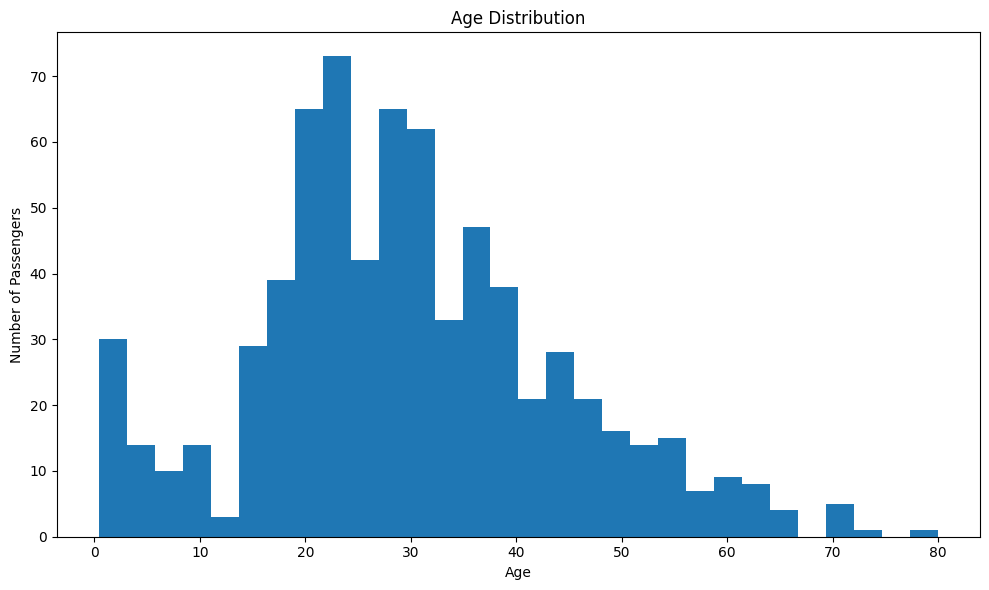

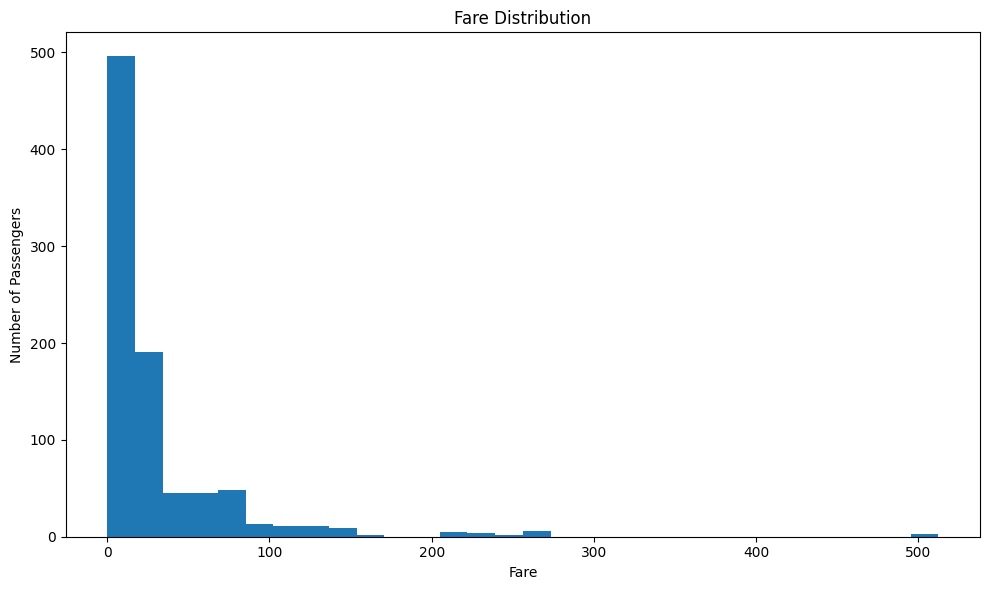

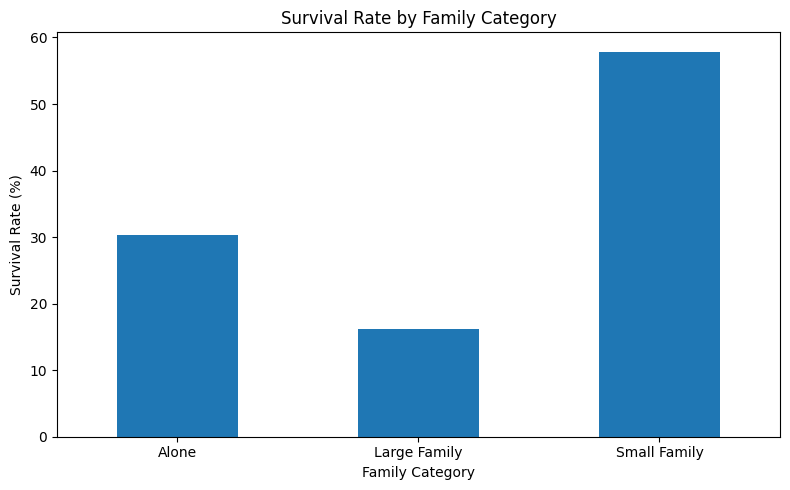

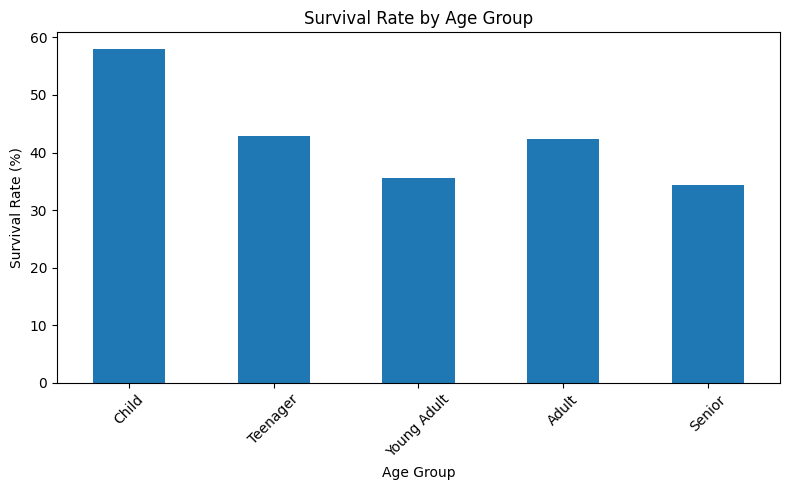

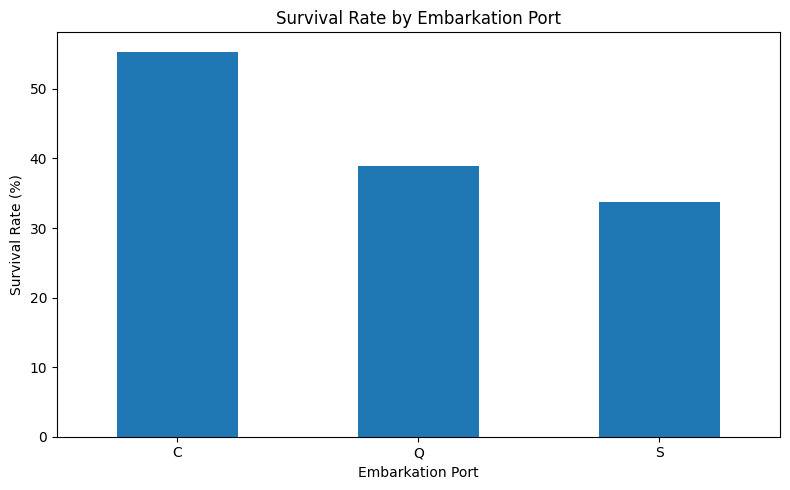


Final EDA Insights
Overall survival rate: 38.38 %
Average passenger age: 29.7
Highest survival rate by gender: female - 74.2 %
Highest survival rate by passenger class: 1 - 62.96 %
Most common gender: male
Most common passenger class: 3
Most common embarkation port: S
Average fare: 32.2

Titanic EDA completed successfully!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train_path = r"C:\Users\Suresh seervi\Desktop\t2\train.csv"
test_path = r"C:\Users\Suresh seervi\Desktop\t2\test.csv"
gender_path = r"C:\Users\Suresh seervi\Desktop\t2\gender_submission.csv"

df = pd.read_csv(train_path)

print("Titanic dataset loaded successfully!")

print("\nFirst 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

print("\nMissing value percentage:")
missing_percentage = (df.isnull().sum() / len(df) * 100).round(2)
print(missing_percentage)

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nUnique values:")
for column in df.columns:
    print(column, ":", df[column].nunique())

print("\nSurvival count:")
print(df["Survived"].value_counts())

print("\nSurvival percentage:")
print(
    df["Survived"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

gender_survival = pd.crosstab(
    df["Sex"],
    df["Survived"]
)

print("\nSurvival by gender:")
print(gender_survival)

gender_survival_rate = (
    df.groupby("Sex")["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

print("\nSurvival rate by gender:")
print(gender_survival_rate)

class_survival = pd.crosstab(
    df["Pclass"],
    df["Survived"]
)

print("\nSurvival by passenger class:")
print(class_survival)

class_survival_rate = (
    df.groupby("Pclass")["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

print("\nSurvival rate by passenger class:")
print(class_survival_rate)

print("\nAge analysis:")
print("Average age:", round(df["Age"].mean(), 2))
print("Median age:", df["Age"].median())
print("Minimum age:", df["Age"].min())
print("Maximum age:", df["Age"].max())

print("\nFare analysis:")
print("Average fare:", round(df["Fare"].mean(), 2))
print("Median fare:", df["Fare"].median())
print("Minimum fare:", df["Fare"].min())
print("Maximum fare:", df["Fare"].max())

print("\nEmbarked passengers:")
print(df["Embarked"].value_counts())

embarked_survival = (
    df.groupby("Embarked")["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

print("\nSurvival rate by embarkation port:")
print(embarked_survival)

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

print("\nFamily size analysis:")
print(
    df.groupby("FamilySize")["Survived"]
    .agg(["count", "mean"])
    .rename(columns={
        "count": "Passengers",
        "mean": "Survival_Rate"
    })
)

def family_category(size):
    if size == 1:
        return "Alone"
    elif size <= 4:
        return "Small Family"
    else:
        return "Large Family"

df["FamilyCategory"] = df["FamilySize"].apply(family_category)

print("\nFamily category:")
print(df["FamilyCategory"].value_counts())

family_survival = (
    df.groupby("FamilyCategory")["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

print("\nSurvival rate by family category:")
print(family_survival)

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 30, 50, 80],
    labels=[
        "Child",
        "Teenager",
        "Young Adult",
        "Adult",
        "Senior"
    ]
)

age_group_survival = (
    df.groupby("AgeGroup", observed=True)["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

print("\nSurvival rate by age group:")
print(age_group_survival)

numeric_columns = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

correlation = df[numeric_columns].corr()

print("\nCorrelation matrix:")
print(correlation)

plt.figure(figsize=(8, 6))
plt.imshow(correlation, interpolation="nearest")
plt.title("Correlation Matrix")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.tight_layout()
plt.savefig('Correlation Matrix.png')
plt.show()

plt.figure(figsize=(8, 5))
df["Survived"].value_counts().sort_index().plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig('Survival Count.png')
plt.show()

plt.figure(figsize=(8, 5))
df["Sex"].value_counts().plot(kind="bar")
plt.title("Passenger Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig('Passenger Distribution by Gender.png')
plt.show()

plt.figure(figsize=(8, 5))
gender_survival_rate.plot(kind="bar")
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig('Survival Rate by Gender.png')
plt.show()

plt.figure(figsize=(8, 5))
class_survival_rate.plot(kind="bar")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig('Survival Rate by Passenger Class.png')
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df["Age"].dropna(), bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.tight_layout()

plt.savefig('Age Distribution.png')
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df["Fare"].dropna(), bins=30)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.tight_layout()

plt.savefig('Fare Distribution.png')
plt.show()

plt.figure(figsize=(8, 5))
family_survival.plot(kind="bar")
plt.title("Survival Rate by Family Category")
plt.xlabel("Family Category")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig('Survival Rate by Family Category.png')
plt.show()

plt.figure(figsize=(8, 5))
age_group_survival.plot(kind="bar")
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('Survival Rate by Age Group.png')
plt.show()

plt.figure(figsize=(8, 5))
embarked_survival.plot(kind="bar")
plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig('Survival Rate by Embarkation Port.png')
plt.show()

overall_survival_rate = df["Survived"].mean() * 100
highest_gender = gender_survival_rate.idxmax()
highest_gender_rate = gender_survival_rate.max()
highest_class = class_survival_rate.idxmax()
highest_class_rate = class_survival_rate.max()

print("\nFinal EDA Insights")
print("Overall survival rate:", round(overall_survival_rate, 2), "%")
print("Average passenger age:", round(df["Age"].mean(), 2))
print(
    "Highest survival rate by gender:",
    highest_gender,
    "-",
    highest_gender_rate,
    "%"
)
print(
    "Highest survival rate by passenger class:",
    highest_class,
    "-",
    highest_class_rate,
    "%"
)
print("Most common gender:", df["Sex"].mode()[0])
print("Most common passenger class:", df["Pclass"].mode()[0])
print("Most common embarkation port:", df["Embarked"].mode()[0])
print("Average fare:", round(df["Fare"].mean(), 2))

print("\nTitanic EDA completed successfully!")